<a href="https://colab.research.google.com/github/Danolight/Modelo_IA/blob/base/modelo1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc
from google.colab import drive

drive.mount('/gdrive')
data = pd.read_csv('/gdrive/MyDrive/Cuba_datasheet.csv')

data

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


,STATION,NAME,DATE,DEWP,FRSHTT,GUST,MAX,MIN,MXSPD,PRCP,SLP,SNDP,STP,TEMP,VISIB,WDSP
0,78256199999,"JARDINES DEL REY, CU",2004-07-13,74.3,0,999.9,89.6,77.0,15.0,0.00,9999.9,999.9,999.9,86.3,5.6,11.1
1,78256199999,"JARDINES DEL REY, CU",2004-07-14,74.6,0,999.9,89.6,75.2,12.0,0.00,9999.9,999.9,999.9,84.9,5.6,6.7
2,78256199999,"JARDINES DEL REY, CU",2004-07-15,73.8,0,999.9,89.6,78.8,15.9,0.00,9999.9,999.9,999.9,84.1,5.6,7.8
3,78256199999,"JARDINES DEL REY, CU",2004-07-16,73.0,10010,999.9,91.4,75.2,9.9,99.99,9999.9,999.9,999.9,80.9,5.6,3.8
4,78256199999,"JARDINES DEL REY, CU",2004-07-17,72.6,10000,999.9,91.4,73.4,12.0,99.99,9999.9,999.9,999.9,80.5,5.5,3.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124481,78268099999,"GUSTAVO RIZO, CU",2024-07-31,77.4,0,999.9,86.0,82.4,9.9,0.00,9999.9,999.9,999.9,84.7,5.7,5.2
124482,78268099999,"GUSTAVO RIZO, CU",2024-08-10,79.5,0,999.9,87.8,84.2,15.0,0.00,9999.9,999.9,999.9,87.1,5.8,13.4
124483,78268099999,"GUSTAVO RIZO, CU",2024-08-13,78.5,0,999.9,87.8,86.0,13.0,0.00,9999.9,999.9,999.9,87.2,6.0,9.7
124484,78268099999,"GUSTAVO RIZO, CU",2024-08-14,78.1,0,999.9,87.8,86.0,9.9,0.00,9999.9,999.9,999.9,87.3,6.1,8.0


In [ ]:

drive.mount('/gdrive')
data1 = pd.read_csv('/gdrive/MyDrive/Cuba_climate.csv')
data1

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


,STATION,NAME,DATE,PRCP,PRCP_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
0,CUM00078369,"PUNTA DE MAISI GUANTANAMO, CU",2010-01-01,0.0,"D,,S",26.6,"H,,S",29.0,",,S",24.0,",,S"
1,CUM00078369,"PUNTA DE MAISI GUANTANAMO, CU",2010-01-02,NaN,NaN,26.7,"H,,S",29.2,",,S",19.8,",,S"
2,CUM00078369,"PUNTA DE MAISI GUANTANAMO, CU",2010-01-03,NaN,NaN,25.1,"H,,S",29.0,",,S",19.8,",,S"
3,CUM00078369,"PUNTA DE MAISI GUANTANAMO, CU",2010-01-04,46.5,",,S",23.7,"H,,S",28.2,",,S",20.7,",,S"
4,CUM00078369,"PUNTA DE MAISI GUANTANAMO, CU",2010-01-05,11.7,",,S",23.3,"H,,S",25.5,",,S",20.7,",,S"
...,...,...,...,...,...,...,...,...,...,...,...
11852,CUM00078355,"CAMAGUEY CAMAGUEY, CU",2016-09-17,0.0,",,S",28.7,"H,,S",32.2,",,S",23.9,",,S"
11853,CUM00078355,"CAMAGUEY CAMAGUEY, CU",2016-09-25,8.4,",,S",28.6,"H,,S",33.1,",,S",23.2,",,S"
11854,CUM00078355,"CAMAGUEY CAMAGUEY, CU",2016-09-29,NaN,NaN,29.8,"H,,S",32.6,",,S",25.2,",,S"
11855,CUM00078355,"CAMAGUEY CAMAGUEY, CU",2016-10-04,NaN,NaN,25.3,"H,,S",32.0,",,S",24.4,",,S"


In [ ]:
def eliminar(data, nombre_columna):
    data = data.drop(columns=[nombre_columna])
    return data

In [ ]:
def renombrar(data, nombre_actual, nuevo_nombre):
      data = data.rename(columns={nombre_actual: nuevo_nombre})
      return data

In [ ]:
print(data.columns.tolist())

['STATION', 'NAME', 'DATE', 'DEWP', 'FRSHTT', 'GUST', 'MAX', 'MIN', 'MXSPD', 'PRCP', 'SLP', 'SNDP', 'STP', 'TEMP', 'VISIB', 'WDSP']


In [ ]:
#Eliminar columnas
data = eliminar(data, "FRSHTT")
data = eliminar(data, "GUST")
data = eliminar(data, "PRCP")
data = eliminar(data, "SLP")
data = eliminar(data, "SNDP")
data = eliminar(data, "STP")
data = eliminar(data, "STATION")
#Llevar datos de millas a Km/h
data["WDSP"] = data["WDSP"] * 1.6093
data["MXSPD"] = data["MXSPD"] * 1.6093
#Llevar datos de F a C
data["MAX"]=((data["MAX"] - 32) * (5/9))
data["MIN"]=((data["MIN"] - 32) * (5/9))
data["TEMP"]=((data["TEMP"] - 32) * (5/9))
data["DEWP"]=((data["DEWP"] - 32) * (5/9))
#Renombrar columnas
data = renombrar(data, "NAME", "ESTACION")
data = renombrar(data, "MAX", "TMAX(°C)")
data = renombrar(data, "MIN", "TMIN(°C)")
data = renombrar(data, "MXSPD", "MXSPD(km/h)")
data = renombrar(data, "WDSP", "WDSP(km/h)")
data = renombrar(data, "TEMP", "AVTEMP(°C)")
data = renombrar(data, "VISIB", "VISIB(km)")
data = renombrar(data, "DEWP", "ROCIO(°C)")
data = renombrar(data, "DATE", "FECHA")
#Guardar nuevo df
data.to_csv("modificado.csv", index=False)

In [ ]:
data3 = pd.read_csv("modificado.csv")
data2 = data3.round(1)
data2

,ESTACION,FECHA,ROCIO(°C),TMAX(°C),TMIN(°C),MXSPD(km/h),AVTEMP(°C),VISIB(km),WDSP(km/h)
0,"JARDINES DEL REY, CU",2004-07-13,23.5,32.0,25.0,24.1,30.2,5.6,17.9
1,"JARDINES DEL REY, CU",2004-07-14,23.7,32.0,24.0,19.3,29.4,5.6,10.8
2,"JARDINES DEL REY, CU",2004-07-15,23.2,32.0,26.0,25.6,28.9,5.6,12.6
3,"JARDINES DEL REY, CU",2004-07-16,22.8,33.0,24.0,15.9,27.2,5.6,6.1
4,"JARDINES DEL REY, CU",2004-07-17,22.6,33.0,23.0,19.3,26.9,5.5,6.0
...,...,...,...,...,...,...,...,...,...
124481,"GUSTAVO RIZO, CU",2024-07-31,25.2,30.0,28.0,15.9,29.3,5.7,8.4
124482,"GUSTAVO RIZO, CU",2024-08-10,26.4,31.0,29.0,24.1,30.6,5.8,21.6
124483,"GUSTAVO RIZO, CU",2024-08-13,25.8,31.0,30.0,20.9,30.7,6.0,15.6
124484,"GUSTAVO RIZO, CU",2024-08-14,25.6,31.0,30.0,15.9,30.7,6.1,12.9


In [ ]:
def eliminar_filas_por_valor(df, valor):
    # Eliminar filas donde cualquier columna tenga el valor especificado
    df.drop(df[df.isin([valor]).any(axis=1)].index, inplace=True)

In [ ]:
eliminar_filas_por_valor(data2, 1609.1)
eliminar_filas_por_valor(data2, 5537.7)
eliminar_filas_por_valor(data2, 999.9)
eliminar_filas_por_valor(data2, 0)

In [ ]:
data2.max()

,0
ESTACION,"MANZANILLO ORIENTE, CU"
FECHA,2024-12-11
ROCIO(°C),27.9
TMAX(°C),46.0
TMIN(°C),33.0
MXSPD(km/h),103.2
AVTEMP(°C),34.8
VISIB(km),31.1
WDSP(km/h),52.1


In [ ]:
import pandas as pd

def dividir_por_estaciones(data, columna_estacion, carpeta_salida="datos_por_estacion"):
    import os
    # Crear la carpeta de salida si no existe
    if not os.path.exists(carpeta_salida):
        os.makedirs(carpeta_salida)
    # Obtener los nombres únicos de las estaciones
    estaciones = data[columna_estacion].unique()

    # Dividir y guardar los datos por estación
    for estacion in estaciones:
        # Filtrar los datos para la estación actual
        datos_estacion = data[data[columna_estacion] == estacion]

        # Crear el nombre del archivo
        nombre_archivo = f"{estacion}.csv"

        # Guardar los datos en un archivo CSV
        datos_estacion.to_csv(nombre_archivo, index=False)
        print(f"Datos de la estación '{estacion}' guardados en '{nombre_archivo}'.")

    print("\nProceso completado. Archivos generados en la carpeta:", carpeta_salida)

In [ ]:
dividir_por_estaciones(data2, "ESTACION", "datos_por_estacion")

Datos de la estación 'JARDINES DEL REY, CU' guardados en 'JARDINES DEL REY, CU.csv'.
Datos de la estación 'ANTONIO MACEO INTERNATIONAL, CU' guardados en 'ANTONIO MACEO INTERNATIONAL, CU.csv'.
Datos de la estación 'JAIME GONZALEZ, CU' guardados en 'JAIME GONZALEZ, CU.csv'.
Datos de la estación 'JUAN GUALBERTO GOMEZ INTERNATIONAL, CU' guardados en 'JUAN GUALBERTO GOMEZ INTERNATIONAL, CU.csv'.
Datos de la estación 'CAYO COCO, CU' guardados en 'CAYO COCO, CU.csv'.
Datos de la estación 'ABEL SANTAMARIA, CU' guardados en 'ABEL SANTAMARIA, CU.csv'.
Datos de la estación 'IGNACIO AGRAMONTE INTERNATIONAL, CU' guardados en 'IGNACIO AGRAMONTE INTERNATIONAL, CU.csv'.
Datos de la estación 'JOSE MARTI INTERNATIONAL, CU' guardados en 'JOSE MARTI INTERNATIONAL, CU.csv'.
Datos de la estación 'MANZANILLO ORIENTE, CU' guardados en 'MANZANILLO ORIENTE, CU.csv'.
Datos de la estación 'FRANK PAIS INTERNATIONAL, CU' guardados en 'FRANK PAIS INTERNATIONAL, CU.csv'.
Datos de la estación 'GUSTAVO RIZO, CU' guarda

In [ ]:
# Lista de nombres de los archivos CSV
archivos_csv = [
    "JARDINES DEL REY, CU.csv",
    "ANTONIO MACEO INTERNATIONAL, CU.csv",
    "JAIME GONZALEZ, CU.csv",
    "JUAN GUALBERTO GOMEZ INTERNATIONAL, CU.csv",
    "CAYO COCO, CU.csv",
    "ABEL SANTAMARIA, CU.csv",
    "IGNACIO AGRAMONTE INTERNATIONAL, CU.csv",
    "JOSE MARTI INTERNATIONAL, CU.csv",
    "MANZANILLO ORIENTE, CU.csv",
    "FRANK PAIS INTERNATIONAL, CU.csv",
    "GUSTAVO RIZO, CU.csv"
]
Final_Data = {}
localizacion = 0
for archivo in archivos_csv:
  datos = pd.read_csv(archivo)
  Final_Data[f"final{localizacion}"] = datos
  datos.to_csv(archivo, index=False)
  print(f"Datosguardados en '{archivo}'.")
  print(Final_Data[f"final{localizacion}"])  # Muestra las primeras filas
  localizacion += 1

Datosguardados en 'JARDINES DEL REY, CU.csv'.
                  ESTACION       FECHA  ROCIO(°C)  TMAX(°C)  TMIN(°C)  \
0     JARDINES DEL REY, CU  2004-07-13       23.5      32.0      25.0   
1     JARDINES DEL REY, CU  2004-07-14       23.7      32.0      24.0   
2     JARDINES DEL REY, CU  2004-07-15       23.2      32.0      26.0   
3     JARDINES DEL REY, CU  2004-07-16       22.8      33.0      24.0   
4     JARDINES DEL REY, CU  2004-07-17       22.6      33.0      23.0   
...                    ...         ...        ...       ...       ...   
7231  JARDINES DEL REY, CU  2024-12-07       18.2      27.0      22.0   
7232  JARDINES DEL REY, CU  2024-12-08       18.7      27.0      23.0   
7233  JARDINES DEL REY, CU  2024-12-09       20.4      27.0      23.0   
7234  JARDINES DEL REY, CU  2024-12-10       22.3      28.0      24.0   
7235  JARDINES DEL REY, CU  2024-12-11       23.1      28.0      24.0   

      MXSPD(km/h)  AVTEMP(°C)  VISIB(km)  WDSP(km/h)  
0            24.1     

In [ ]:
def verificar_separacion_tiempos(data, columna_fecha='FECHA'):

    # Asegurarse de que la columna de fechas esté en formato datetime
    data[columna_fecha] = pd.to_datetime(data[columna_fecha])

    # Ordenar los datos por la columna de fechas (si no están ya ordenados)
    data = data.sort_values(by=[columna_fecha])

    # Calcular la diferencia entre fechas consecutivas
    diferencias = data[columna_fecha].diff().dt.days  # La diferencia en días

    return diferencias

In [ ]:
def verificar_nulos_y_duplicados(data):
    # Verificar valores nulos
    nulos = data.isnull().sum()  # Cuenta los valores nulos por columna

    # Verificar valores duplicados
    duplicados = data.duplicated().sum()  # Cuenta las filas duplicadas

    # Retornar los resultados
    return {'nulos': nulos, 'duplicados': duplicados}

In [ ]:
def extraer(numero):
    dfs = Final_Data[f"final{numero}"]
    return dfs

In [ ]:
datas = extraer(7)
diferencia = verificar_separacion_tiempos(datas)
print(diferencia)

0        NaN
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
20124    1.0
20125    1.0
20126    1.0
20127    1.0
20128    1.0
Name: FECHA, Length: 20129, dtype: float64


In [ ]:
resultados = verificar_nulos_y_duplicados(extraer(7))
# Mostrar los resultados
print("Valores nulos por columna:")
print(resultados['nulos'])
print("\nNúmero de filas duplicadas:", resultados['duplicados'])

Valores nulos por columna:
ESTACION       0
FECHA          0
ROCIO(°C)      0
TMAX(°C)       0
TMIN(°C)       0
MXSPD(km/h)    0
AVTEMP(°C)     0
VISIB(km)      0
WDSP(km/h)     0
dtype: int64

Número de filas duplicadas: 0


In [ ]:
JG = Final_Data["final7"].drop(columns="FECHA")
JG = JG.drop(columns="ESTACION")
JG

,ROCIO(°C),TMAX(°C),TMIN(°C),MXSPD(km/h),AVTEMP(°C),VISIB(km),WDSP(km/h)
0,17.9,26.1,18.9,40.4,22.4,9.3,17.4
1,16.2,26.1,16.1,32.2,20.9,8.9,13.5
2,17.1,27.8,16.1,32.2,21.6,9.5,13.2
3,17.4,27.8,17.2,32.2,22.4,9.8,16.4
4,19.1,27.8,20.0,24.1,23.3,9.9,16.7
...,...,...,...,...,...,...,...
20124,17.3,27.0,13.9,22.5,20.3,4.5,9.0
20125,17.2,26.1,14.0,20.9,21.3,5.3,9.0
20126,17.7,28.0,17.9,12.9,21.8,5.7,8.5
20127,20.8,28.0,20.0,12.9,23.6,5.4,8.9


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

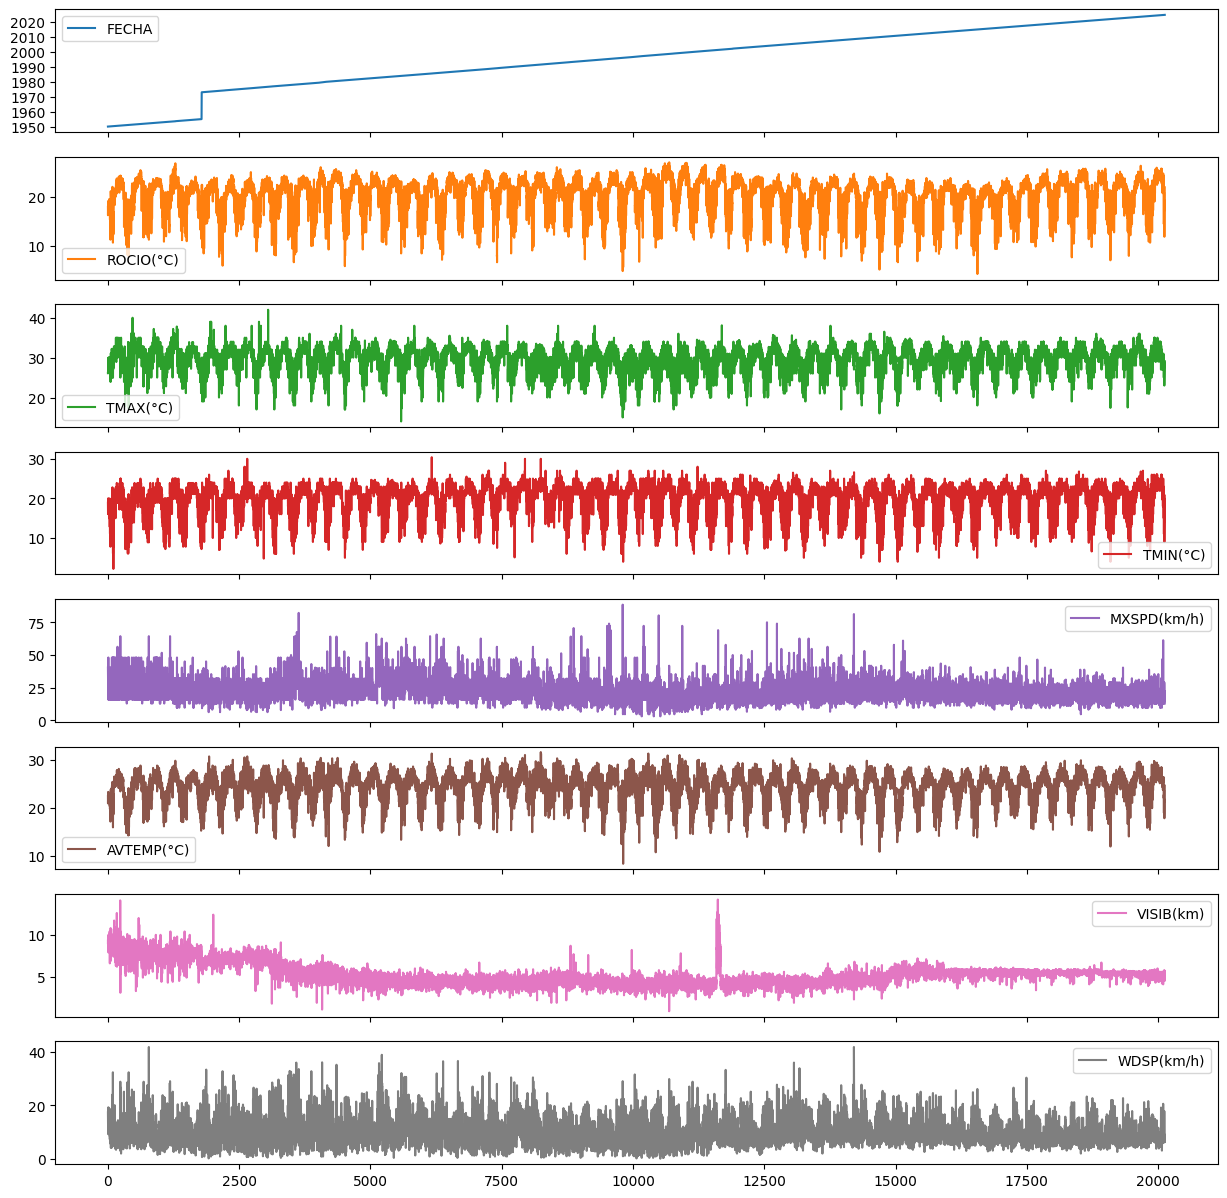

In [ ]:
graf = Final_Data["final7"]
cols = graf.columns
N = graf.shape[0]
plots = graf[cols[1:]][0:N]
plots.index = graf.index[0:N]
plots.plot(subplots=True, figsize=(15,15))

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

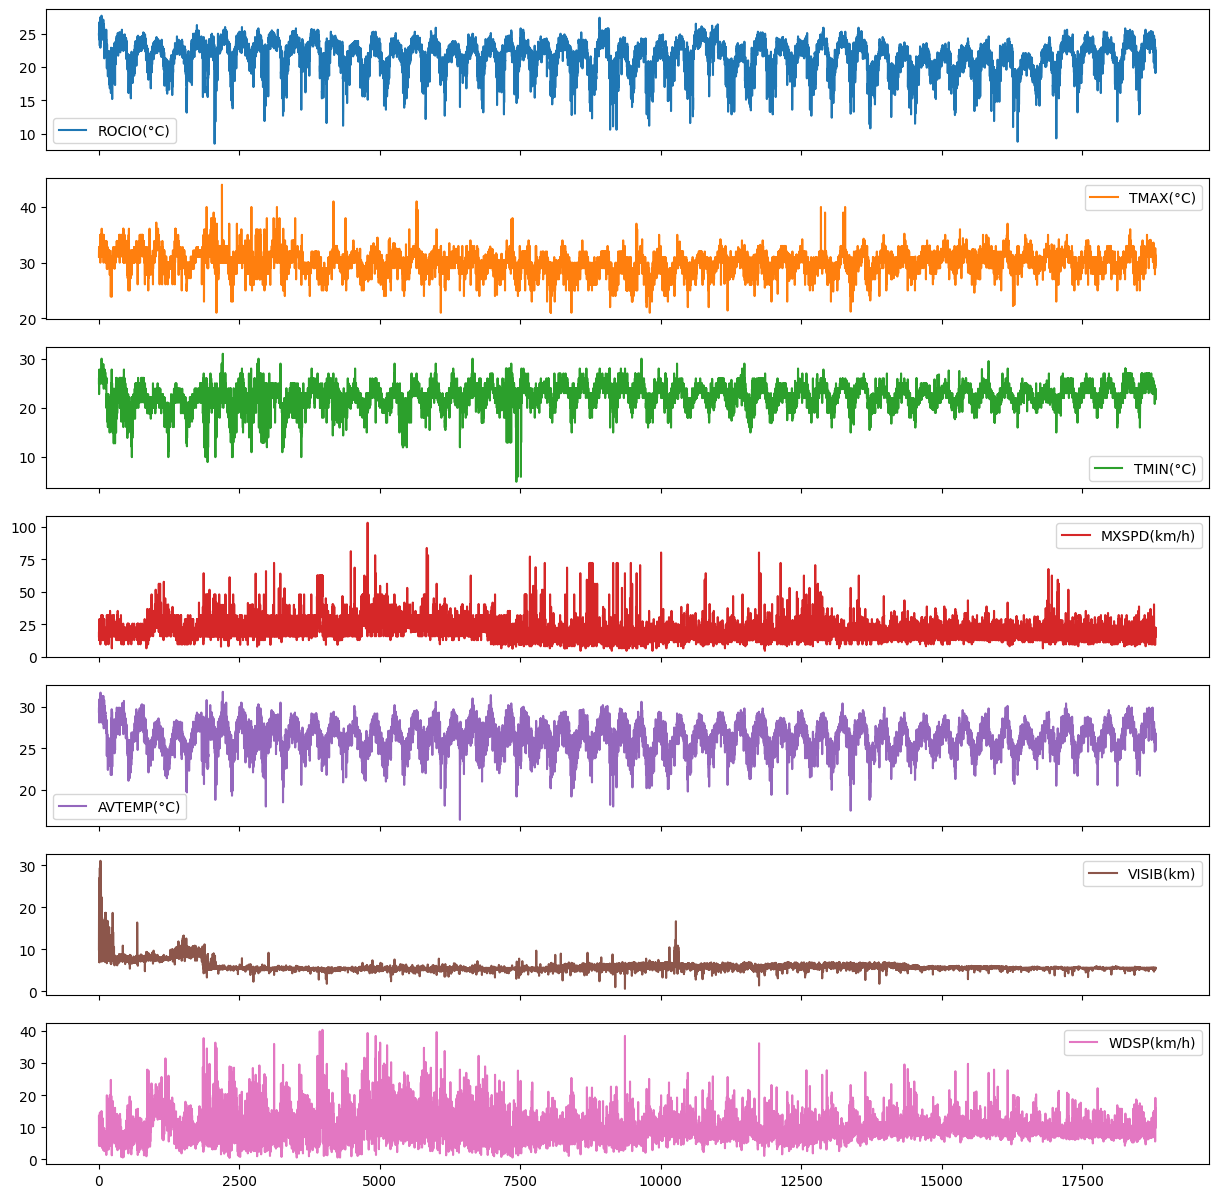

In [ ]:
graf = Final_Data["final1"]
cols = graf.columns
N = graf.shape[0]
plots = graf[cols[1:]][0:N]
plots.index = graf.index[0:N]
plots.plot(subplots=True, figsize=(15,15))


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

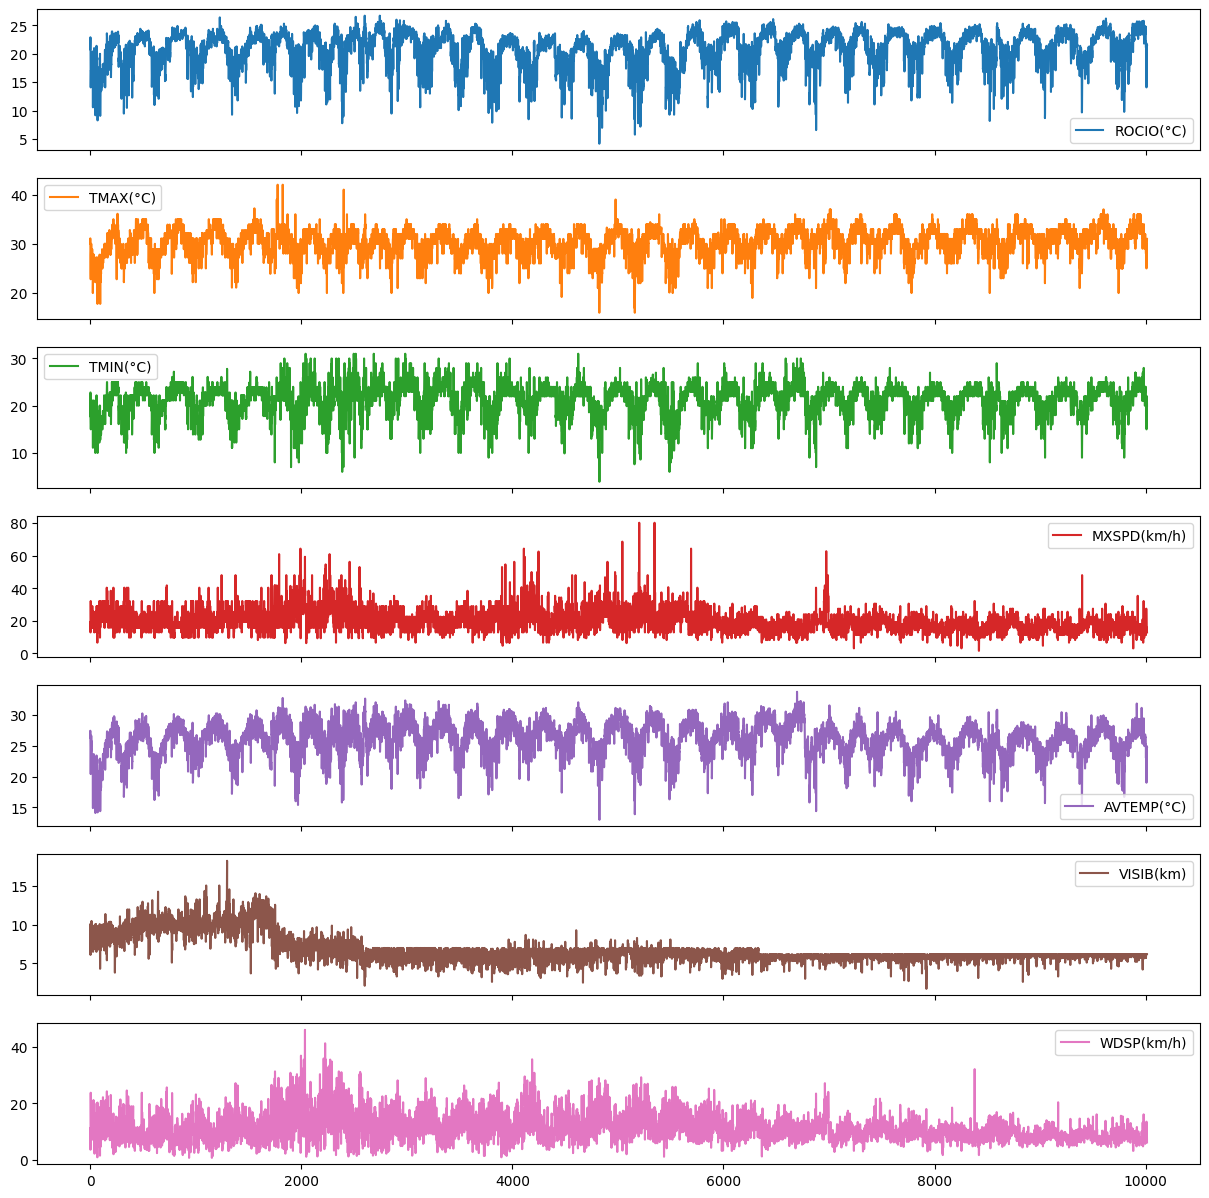

In [ ]:
graf = Final_Data["final2"]
cols = graf.columns
N = graf.shape[0]
plots = graf[cols[1:]][0:N]
plots.index = graf.index[0:N]
plots.plot(subplots=True, figsize=(15,15))

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

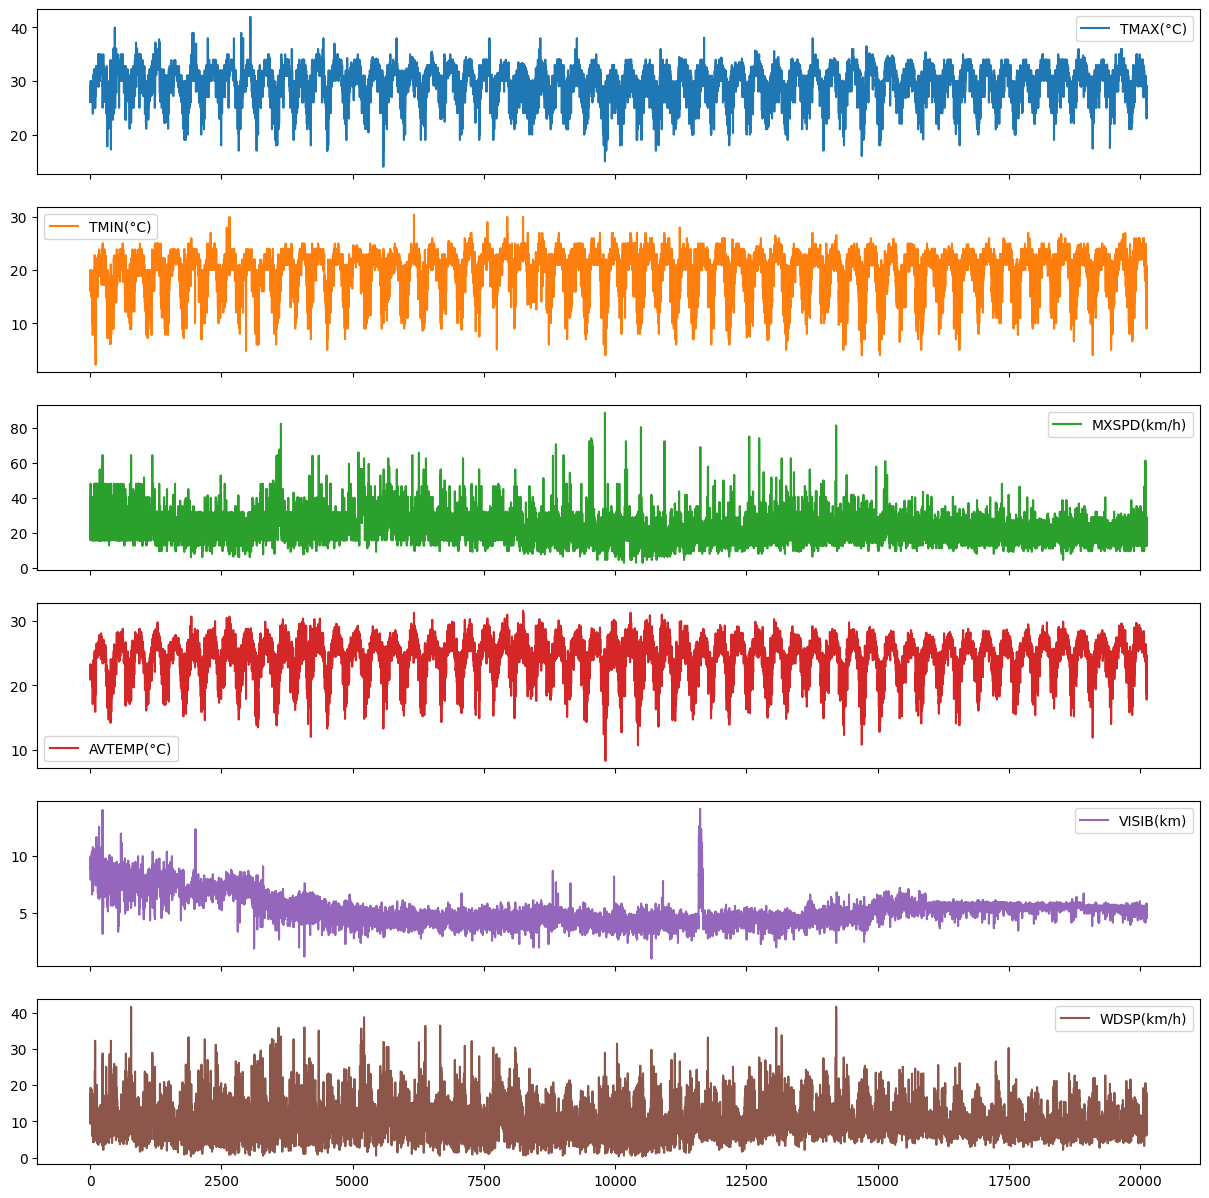

In [ ]:
graf = JG
cols = graf.columns
N = graf.shape[0]
plots = graf[cols[1:]][0:N]
plots.index = graf.index[0:N]
plots.plot(subplots=True, figsize=(15,15))

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()
# Aplicamos la normalización
climate_data_scaled = scaler.fit_transform(JG)

# Función para crear las secuencias
def create_sequences(data, window_size=30):
    sequences = []
    labels = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i + window_size])
        labels.append(data[i + window_size])
    return np.array(sequences), np.array(labels)

# Crear las secuencias
window_size = 30  # Número de días en la ventana temporal
X, y = create_sequences(climate_data_scaled, window_size)

# Dividir los datos en entrenamiento, validación y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [ ]:
pip install keras-tuner

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow import keras
import keras_tuner as kt

def build_model(hp):
    # Define el número de capas LSTM como un hiperparámetro
    num_layers = hp.Int('num_layers', 1, 4)  # Número de capas LSTM

    model = keras.Sequential()

    # Primera capa LSTM (siempre presente)
    model.add(layers.LSTM(
        units=hp.Int('units_0', min_value=32, max_value=256, step=32),  # Número de unidades en la capa LSTM
        return_sequences=(num_layers > 1),  # Devuelve secuencias si hay más de una capa LSTM
        activation='tanh',  # Activación tanh (recomendada para LSTM)
        kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 0.001, 0.01, step=0.001)),  # Regularización L2
        dropout=hp.Float('dropout_rate', 0.2, 0.5, step=0.1),  # Dropout para evitar overfitting
        input_shape=(X_train.shape[1], 7)  # Tamaño de la ventana y número de parámetros climáticos
    ))

    # Capas LSTM adicionales (según el número definido por el hiperparámetro)
    for i in range(1, num_layers):
        model.add(layers.LSTM(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),  # Número de unidades
            return_sequences=(i < num_layers - 1),  # Devuelve secuencias excepto en la última capa LSTM
            activation='tanh',
            kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 0.001, 0.01, step=0.001)),  # Regularización L2
            dropout=hp.Float('dropout_rate', 0.2, 0.5, step=0.1)  # Dropout
        ))

    # Capa densa de salida (7 salidas para predecir los 7 parámetros)
    model.add(layers.Dense(7))

    # Selección del optimizador como hiperparámetro
    optimizer = hp.Choice('optimizer', ['adam'])
    # Asignar optimizer_instance fuera de la condición if
    if optimizer == 'adam':
        optimizer_instance = keras.optimizers.Adam(learning_rate=hp.Float('adam_lr', 1e-4, 1e-2, sampling='log'))
    else:
        # Agregar un optimizador predeterminado o generar un error para optimizadores no compatibles
        optimizer_instance = keras.optimizers.Adam()  # Por defecto a Adam si no se especifica

    # Compilación del modelo
    model.compile(
        optimizer=optimizer_instance,  # Optimizador ajustado dinámicamente
        loss=keras.losses.MeanSquaredError(),  # Pérdida basada en el error cuadrático medio
        metrics=[keras.metrics.MeanAbsoluteError()]  # Métrica adicional: error absoluto medio
    )

    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Configuración del tuner
tuner = kt.Hyperband(
    build_model,  # Función para construir el modelo
    objective='val_loss',  # Minimizar la pérdida en validación
    max_epochs=20,  # Épocas máximas por modelo
    hyperband_iterations=3,  # Iteraciones para búsqueda de hiperparámetros
    directory='tuner_results',
    project_name='climate_lstm_optimization'
)

# Proceso de búsqueda
tuner.search(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, lr_scheduler]  # Integración de callbacks
)

Trial 42 Complete [00h 07m 25s]
val_loss: 0.01462123729288578

Best val_loss So Far: 0.009476090781390667
Total elapsed time: 01h 51m 07s

Search: Running Trial #43

Value             |Best Value So Far |Hyperparameter
3                 |1                 |num_layers
224               |160               |units_0
0.009             |0.003             |l2_reg
0.4               |0.2               |dropout_rate
sgd               |adam              |optimizer
0.0070333         |0.0082949         |adam_lr
32                |160               |units_1
0.00010813        |0.0029959         |rmsprop_lr
256               |160               |units_2
192               |32                |units_3
0.00058506        |0.0001402         |sgd_lr
6                 |6                 |tuner/epochs
0                 |2                 |tuner/initial_epoch
2                 |3                 |tuner/bracket
0                 |1                 |tuner/round

Epoch 1/6
453/453 ━━━━━━━━━━━━━━━━━━━━ 76s 158ms/ste

In [ ]:
model.summary()

In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejores hiperparámetros: {best_hps.values}")

# Entrenar el modelo final con los mejores hiperparámetros
model = tuner.hypermodel.build(best_hps)
model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[early_stopping, lr_scheduler])


In [ ]:
model.summary()

In [ ]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Pérdida en el conjunto de prueba: {test_loss}')
print(f'Error absoluto medio en el conjunto de prueba: {test_mae}')

In [ ]:
# Hacer predicciones con el modelo en los datos de prueba
y_pred = model.predict(X_test)

# Calcular RMSE
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f'RMSE: {rmse}')

In [ ]:
from sklearn.metrics import r2_score

# Calcular R²
r2 = r2_score(y_test, y_pred)
print(f'R²: {r2}')

In [ ]:
import matplotlib.pyplot as plt

# Comparar las predicciones con los valores reales
plt.figure(figsize=(10, 6))

# Graficar los 7 parámetros climáticos (en este caso, se puede hacer una gráfica por parámetro o todos juntos)
for i in range(7):
    plt.subplot(3, 3, i + 1)  # 3 filas, 3 columnas
    plt.plot(y_test[:, i], label='Valor real')
    plt.plot(y_pred[:, i], label='Predicción')
    plt.title(f'Parámetro {i + 1}')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Calcular los errores (diferencia entre predicciones y valores reales)
errors = y_pred - y_test

# Graficar los errores
plt.figure(figsize=(10, 6))
plt.plot(errors)
plt.title('Errores (Predicción - Valor Real)')
plt.xlabel('Índice de Muestra')
plt.ylabel('Error')
plt.show()

In [ ]:
import seaborn as sns

# Correlación entre los errores de las diferentes salidas
error_corr = np.corrcoef(errors.T)  # Transponer para correlacionar cada parámetro
sns.heatmap(error_corr, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=[f'Parámetro {i+1}' for i in range(7)], yticklabels=[f'Parámetro {i+1}' for i in range(7)])
plt.title('Correlación de Errores entre Parámetros Predichos')
plt.show()